Number of detected objects: 2


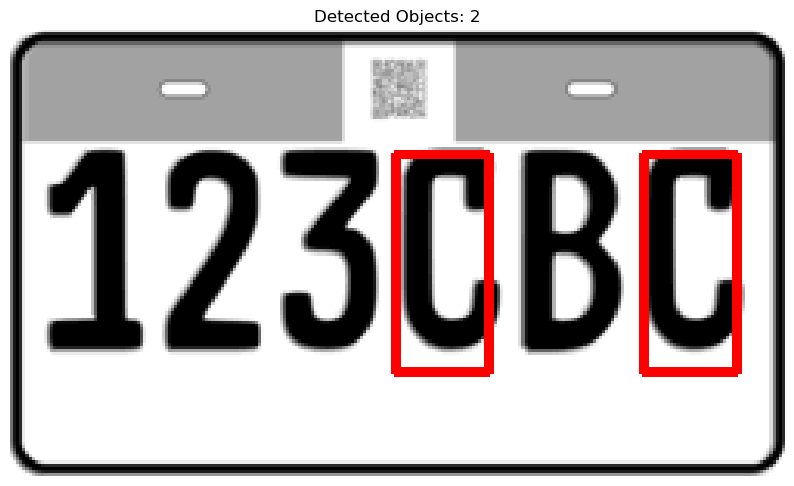

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity


def compute_manual_hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2)
):
    # --- 1. Compute Gradients ---
    # Using Sobel filters to get gradients in x and y directions
    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=1)
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=1)

    # Compute gradient magnitude and orientation (in degrees)
    magnitude = np.sqrt(gx ** 2 + gy ** 2)
    orientation = np.rad2deg(np.arctan2(gy, gx)) % 360  # Unsigned orientation

    # --- 2. Create Cell Histograms ---
    sy, sx = image.shape
    cx, cy = pixels_per_cell
    bx, by = cells_per_block

    n_cellsx = sx // cx
    n_cellsy = sy // cy

    # `orientation_histogram` will store a histogram for each cell
    orientation_histogram = np.zeros((n_cellsy, n_cellsx, orientations))

    for i in range(n_cellsy):
        for j in range(n_cellsx):
            # Get the magnitude and orientation for the current cell
            cell_mag = magnitude[i * cy:(i + 1) * cy, j * cx:(j + 1) * cx]
            cell_ori = orientation[i * cy:(i + 1) * cy, j * cx:(j + 1) * cx]

            # Calculate the histogram for the cell, weighted by magnitude
            hist, _ = np.histogram(
                cell_ori,
                bins=orientations,
                range=(0, 360),
                weights=cell_mag
            )
            orientation_histogram[i, j, :] = hist

    # --- 3. Normalize over Blocks and Create Feature Vector ---
    hog_vector = []
    # Loop over blocks (with overlap)
    for i in range(n_cellsy - by + 1):
        for j in range(n_cellsx - bx + 1):
            # Get the cells for the current block
            block = orientation_histogram[i:i + by, j:j + bx, :]

            # L2-normalize the block
            block = block.flatten()
            norm = np.sqrt(np.sum(block ** 2) + 1e-5)  # Add epsilon for stability
            block = block / norm

            hog_vector.extend(block)

    return np.array(hog_vector)


def detect_objects_with_hog(
        template_path,
        scene_path,
        window_dim=(10, 25),
        window_step=(5, 5),
        hog_orientations=9,
        hog_pixels_per_cell=(8, 8),
        hog_cells_per_block=(2, 2),
        similarity_threshold=0.1
):
    """
    Detects objects in a scene using HOG features and a sliding window.
    """
    # --- 1. Load Images ---
    try:
        template_img = cv2.imread(template_path, cv2.IMREAD_GRAYSCALE)
        scene_img = cv2.imread(scene_path, cv2.IMREAD_GRAYSCALE)

        if template_img is None:
            raise FileNotFoundError(f"Template image not found at: {template_path}")
        if scene_img is None:
            raise FileNotFoundError(f"Scene image not found at: {scene_path}")

    except Exception as e:
        print(f"Error loading images: {e}")
        return None, 0

    # --- 2. Prepare Template ---
    template_resized = cv2.resize(template_img, window_dim, interpolation=cv2.INTER_AREA)

    # Compute HOG features for the template using the manual function
    template_hog_fd = compute_manual_hog(
        template_resized,
        orientations=hog_orientations,
        pixels_per_cell=hog_pixels_per_cell,
        cells_per_block=hog_cells_per_block
    )
    template_hog_fd = template_hog_fd.reshape(1, -1)

    # --- 3. Sliding Window and Detection ---
    detections = []
    scene_h, scene_w = scene_img.shape
    step_x, step_y = window_step
    win_w, win_h = window_dim

    for y in range(0, scene_h - win_h + 1, step_y):
        for x in range(0, scene_w - win_w + 1, step_x):
            window = scene_img[y:y + win_h, x:x + win_w]

            # Compute HOG features for the window using the manual function
            window_hog_fd = compute_manual_hog(
                window,
                orientations=hog_orientations,
                pixels_per_cell=hog_pixels_per_cell,
                cells_per_block=hog_cells_per_block
            )

            if window_hog_fd is None or window_hog_fd.size == 0:
                continue

            window_hog_fd = window_hog_fd.reshape(1, -1)

            sim_score = cosine_similarity(template_hog_fd, window_hog_fd)[0][0]

            if sim_score >= similarity_threshold:
                detections.append((x, y, sim_score))

    # --- 4. Non-Maximum Suppression (NMS) ---
    detections = sorted(detections, key=lambda r: r[2], reverse=True)
    final_detections = []
    for (x1, y1, score1) in detections:
        is_overlapping = False
        for (x2, y2, score2) in final_detections:
            if (x1 < x2 + win_w and x1 + win_w > x2 and
                    y1 < y2 + win_h and y1 + win_h > y2):
                is_overlapping = True
                break
        if not is_overlapping:
            final_detections.append((x1, y1, score1))

    # --- 5. Draw Rectangles ---
    scene_with_detections = cv2.cvtColor(scene_img, cv2.COLOR_GRAY2BGR)
    for (x, y, score) in final_detections:
        cv2.rectangle(scene_with_detections, (x, y), (x + win_w, y + win_h), (0, 0, 255), 2)

    return scene_with_detections, len(final_detections)


# ---------- Main Execution ----------
if __name__ == "__main__":
    # --- Input Parameters ---
    TEMPLATE_IMAGE_PATH = r"C:\Users\91988\Downloads\image 1.png"
    SCENE_IMAGE_PATH = r"C:\Users\91988\Downloads\image 2.jpg"

    WINDOW_SIZE = (30, 70)
    WINDOW_STEP = (4, 4)

    # HOG Parameters
    ORIENTATIONS = 9
    PIXELS_PER_CELL = (8, 8)
    CELLS_PER_BLOCK = (2, 2)

    # Similarity threshold: manual HOG may need a different threshold
    SIMILARITY_THRESHOLD = 0.87

    # --- Run Detection ---
    final_image, object_count = detect_objects_with_hog(
        template_path=TEMPLATE_IMAGE_PATH,
        scene_path=SCENE_IMAGE_PATH,
        window_dim=WINDOW_SIZE,
        window_step=WINDOW_STEP,
        hog_orientations=ORIENTATIONS,
        hog_pixels_per_cell=PIXELS_PER_CELL,
        hog_cells_per_block=CELLS_PER_BLOCK,
        similarity_threshold=SIMILARITY_THRESHOLD
    )

    # --- Display Results ---
    if final_image is not None:
        print(f"Number of detected objects: {object_count}")

        plt.figure(figsize=(10, 8))
        plt.imshow(cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB))
        plt.title(f'Detected Objects: {object_count}')
        plt.axis('off')
        plt.show()
